# Supplemental Fig. S4: scNMT-seq mouse gastrulation (RNA, CpG, GpC)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/reproducibility/api/figS4_scnmt.ipynb)

Three modalities from the same cells (Argelaguet et al. 2019): RNA with a Gaussian likelihood on log-normalized expression, and gene-body CpG methylation and GpC accessibility with beta-binomial likelihoods on per-feature (methylated, covered) read counts. The data are the parsed gene-body matrices hosted on Zenodo, produced from the EBI's parsed bundle with the same reader settings as the archived analysis (no QC or feature filtering, minimum coverage 1 for CpG and GpC), so the 33 GB source archive is not needed. Settings follow the archived notebook `UniVI_manuscript_GR-Supple_____scNMT-seq_mouse_gastrulation_data.ipynb`.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.1"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch

import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.datasets import build_univi_inputs_from_scnmt_triplet
from univi.evaluation import compute_foscttm, encode_adata, encode_moe_gates_from_tensors
from univi.plotting import plot_moe_gate_summary, write_gates_to_obs
from univi.utils.seed import set_seed
from univi.workflows import make_loader, stack_embeddings

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)

C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 5000   # archived notebook: 5000 with early stopping (patience 300)

## Data and inputs

Each modality keeps what the likelihoods need: RNA counts, and for CpG and GpC the observed fraction in `.X` plus methylated/accessible (`*_successes`) and covered (`*_total_count`) read counts as layers. `build_univi_inputs_from_scnmt_triplet` log-normalizes RNA and returns the reconstruction targets that point the beta-binomial decoders at those layers. `obs["split"]` holds the article's seed-0 85/5/10 split (969/57/114 cells).

In [4]:
triplet = uds.load("scnmt_gastrulation")
built = build_univi_inputs_from_scnmt_triplet(triplet["rna"], triplet["cpg"], triplet["gpc"])
adatas, targets = built["adata_dict"], built["recon_targets_spec"]

if "split" in adatas["rna"].obs:
    split = adatas["rna"].obs["split"].astype(str).to_numpy()
    splits = {k: np.flatnonzero(split == k) for k in ("train", "val", "test")}
else:                                            # the article's split: seed 0, 85/5/10
    n = adatas["rna"].n_obs
    perm = np.random.default_rng(0).permutation(n)
    n_tr, n_va = int(0.85 * n), int(0.05 * n)
    splits = {"train": np.sort(perm[:n_tr]), "val": np.sort(perm[n_tr:n_tr + n_va]), "test": np.sort(perm[n_tr + n_va:])}
parts = {k: {m: a[i].copy() for m, a in adatas.items()} for k, i in splits.items()}
print({m: a.shape for m, a in adatas.items()}, {k: len(v) for k, v in splits.items()})

scnmt_gastrulation_rna.h5ad: 100%|██████████| 46.8M/46.8M [01:10<00:00, 667kB/s]
scnmt_gastrulation_cpg.h5ad: 100%|██████████| 74.4M/74.4M [00:58<00:00, 1.27MB/s]
scnmt_gastrulation_gpc.h5ad: 100%|██████████| 103M/103M [01:08<00:00, 1.51MB/s] 


{'rna': (1140, 22084), 'cpg': (1140, 18285), 'gpc': (1140, 18325)} {'train': 969, 'val': 57, 'test': 114}


In [5]:
dims = {m: a.n_vars for m, a in adatas.items()}
cfg = UniVIConfig(
    latent_dim=20, beta=1.35, gamma=6.25, encoder_dropout=0.010, decoder_dropout=0.005,
    kl_anneal_start=30, kl_anneal_end=60, align_anneal_start=40, align_anneal_end=70,
    modalities=[
        ModalityConfig("rna", dims["rna"], [512, 256, 128, 64], [64, 128, 256, 512], likelihood="gaussian"),
        ModalityConfig("cpg", dims["cpg"], [256, 128, 64], [64, 128, 256], likelihood="beta_binomial"),
        ModalityConfig("gpc", dims["gpc"], [256, 128, 64], [64, 128, 256], likelihood="beta_binomial"),
    ],
)
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
UniVITrainer(
    model, make_loader(parts["train"], batch_size=24, shuffle=True, drop_last=True, recon_targets_spec=targets),
    make_loader(parts["val"], batch_size=256, recon_targets_spec=targets),
    TrainingConfig(n_epochs=N_EPOCHS, batch_size=24, lr=1e-3, weight_decay=1e-4, device=device,
                   early_stopping=True, patience=300, best_epoch_warmup=70, log_every=100),
).fit();

[2026-09-21 18:58:20,859] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-21 18:58:20,860] [UniVITrainer] [INFO]   n_epochs: 5000
[2026-09-21 18:58:20,861] [UniVITrainer] [INFO]   batch_size: 24
[2026-09-21 18:58:20,861] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-21 18:58:20,862] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-21 18:58:20,863] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-21 18:58:20,863] [UniVITrainer] [INFO]   log_every: 100
[2026-09-21 18:58:20,864] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-21 18:58:20,864] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-21 18:58:20,864] [UniVITrainer] [INFO]   seed: 0
[2026-09-21 18:58:20,865] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-21 18:58:20,865] [UniVITrainer] [INFO]   patience: 300
[2026-09-21 18:58:20,865] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-21 18:58:20,866] [UniVITrainer] [INFO]   best_epoch_warmup: 70
Training UniVI:   0%|          | 0/5000 [00:00<?, ?it/s][2026-09-21 18:58:24,713] [U

## Inductive (held-out cells) and transductive (all cells) evaluation

With about a hundred test cells, the article reports both: test cells only, and the same checkpoint applied to every cell.

In [6]:
def foscttm_all(sets):
    z = {m: encode_adata(model, a, modality=m, device=device, latent="modality_mean") for m, a in sets.items()}
    return {f"{a}–{b}": compute_foscttm(z[a], z[b]) for a, b in [("rna", "cpg"), ("rna", "gpc"), ("cpg", "gpc")]}

pd.DataFrame({"inductive (test)": foscttm_all(parts["test"]), "transductive (all)": foscttm_all(adatas)}).round(3)

,inductive (test),transductive (all)
rna–cpg,0.167,0.025
rna–gpc,0.214,0.036
cpg–gpc,0.127,0.024


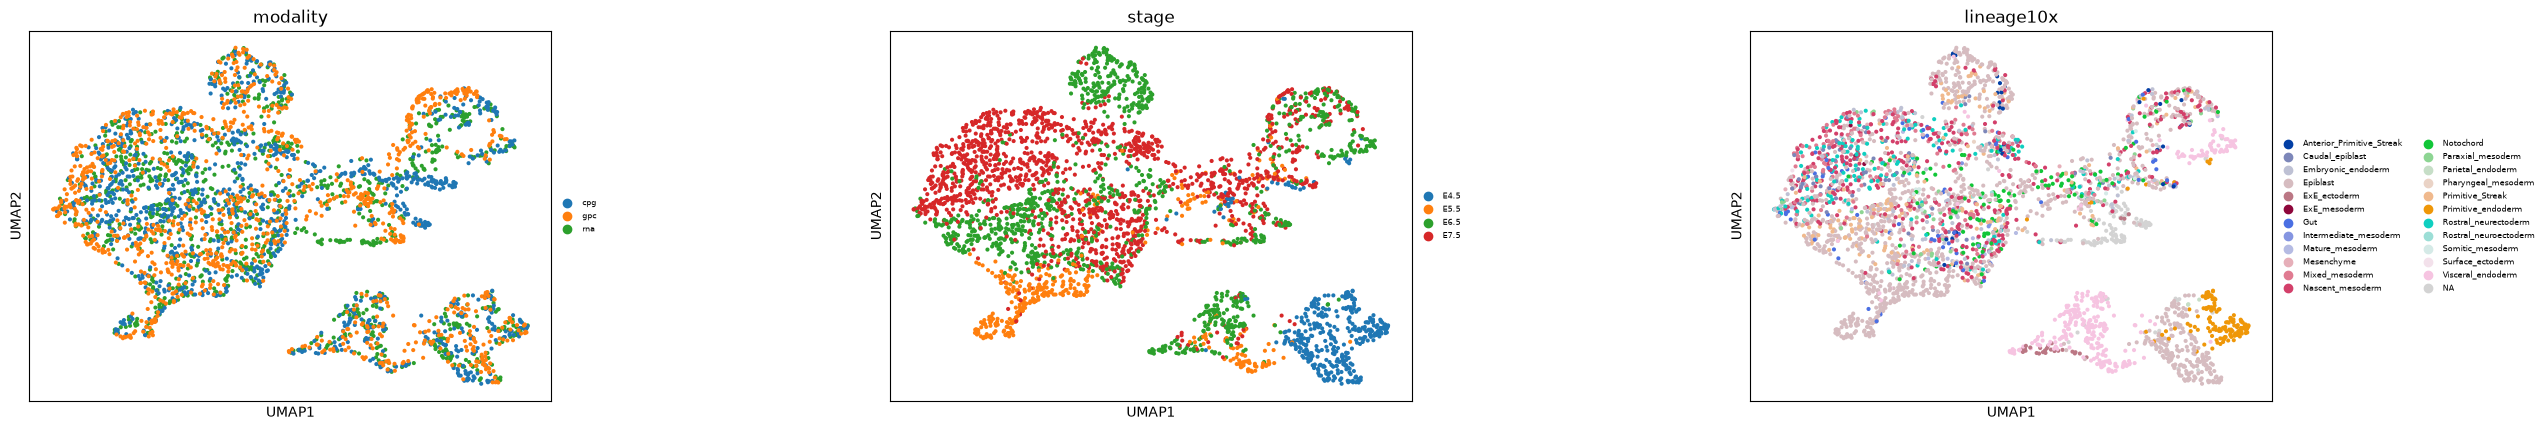

In [7]:
color = [c for c in ["modality", "stage", "lineage10x"] if c == "modality" or c in adatas["rna"].obs]
joint = stack_embeddings(model, [("all", m, a) for m, a in adatas.items()], device=device)
sc.pp.neighbors(joint, use_rep="X_univi", n_neighbors=15)
sc.tl.umap(joint, random_state=0)
sc.pl.umap(joint, color=color, wspace=0.5, legend_fontsize=6)

## Modality contributions by lineage (Supplemental Fig. S4E, J)

Precision-based weights: each modality's share of the fused posterior precision, averaged per lineage.

{'rna': 0.3141788840293884, 'cpg': 0.33112698793411255, 'gpc': 0.35469409823417664}


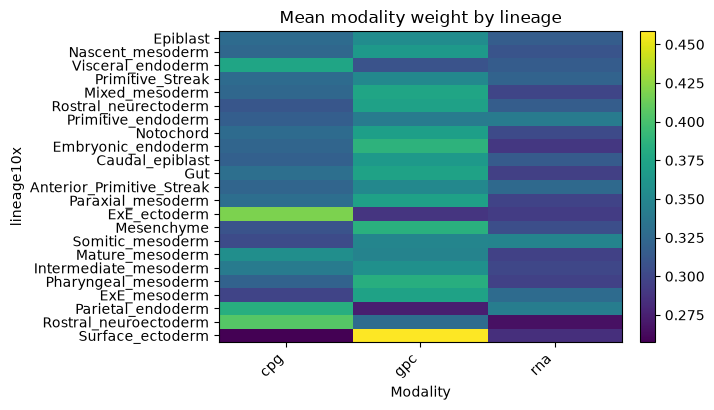

In [8]:
w = encode_moe_gates_from_tensors(model, {m: a.X for m, a in adatas.items()}, device=device, kind="effective_precision")
write_gates_to_obs(adatas["rna"], w["weights"], modality_names=w["modality_order"], gate_prefix="weight")
print(w["per_modality_mean"])
if "lineage10x" in adatas["rna"].obs:
    plot_moe_gate_summary(adatas["rna"], gate_prefix="weight", groupby="lineage10x", title="Mean modality weight by lineage")